In [1]:
!nvidia-smi

Thu Jun  4 16:27:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# =========================
# CELL 1A — MOUNT GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =========================
# CELL 1B — IMPORTS + CONFIG
# =========================
import os, json, random, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB0

# ── EfficientNetB0: NO preprocess_input — float32 0-255, normalisasi internal ──

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# PATH CONFIG — PROJECT
# =========================
PROJECT_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research"

DATASET_NAME    = "MultiClient"
EXPERIMENT_NAME = "exp6_fl_dann_loss_asc"
MODEL_NAME      = "efficientnetb0"

BASE_RESULT_DIR = os.path.join(PROJECT_DIR, "results", DATASET_NAME, EXPERIMENT_NAME, MODEL_NAME)
MODELS_DIR      = os.path.join(BASE_RESULT_DIR, "models")
LOGS_DIR        = os.path.join(BASE_RESULT_DIR, "logs")
FIGURES_DIR     = os.path.join(BASE_RESULT_DIR, "figures")

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(LOGS_DIR,    exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# =========================
# PATH CONFIG — CLIENTS
# =========================
DDR_NPZ_PATH       = "/content/drive/MyDrive/S-Class/Orion/OrionFL/DDR_Dataset/DDR_dataset_224.npz"
DDR_LABEL_PATH     = "/content/drive/MyDrive/S-Class/Orion/OrionFL/DDR_Dataset/DR_grading.csv"
EYEPACS_NPZ_PATH   = "/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/EyePACS_dataset_224.npz"
EYEPACS_LABEL_PATH = "/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/trainLabels.csv"
APTOS_NPZ_PATH     = "/content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed/orion_dr_224.npz"

# =========================
# FL CONFIG
# =========================
IMG_SIZE               = (224, 224)
BATCH_SIZE             = 32
NUM_CLASSES            = 5
NUM_CLIENTS            = 3
CLIENT_NAMES           = ["DDR", "EyePACS", "APTOS"]

FL_ROUNDS              = 15
EPOCHS_LOCAL_STAGE1    = 3
EPOCHS_LOCAL_STAGE2    = 3

LEARNING_RATE_STAGE1   = 1e-3
LEARNING_RATE_STAGE2   = 1e-6
UNFREEZE_LAST_N_LAYERS = 20

SORT_STRATEGY          = "loss_ascending"
# DANN hyperparameters
LAMBDA_GAMMA           = 10.0
DOMAIN_LOSS_WEIGHT     = 0.2
DANN_WARMUP_ROUNDS     = 3   # rounds 1-3: label-only, DANN starts round 4
FEATURE_DIM            = 128
NUM_DOMAINS            = 3

# =========================
# DEBUG INFO
# =========================
print("TensorFlow :", tf.__version__)
print("MODEL_NAME :", MODEL_NAME)
print("SORT_STRATEGY:", SORT_STRATEGY)
print("FL_ROUNDS  :", FL_ROUNDS)
print('Sort: dynamic per round')
print('LAMBDA_GAMMA:', LAMBDA_GAMMA)
print()
print("DDR_NPZ    :", os.path.exists(DDR_NPZ_PATH))
print("DDR_LABEL  :", os.path.exists(DDR_LABEL_PATH))
print("EYEPACS_NPZ:", os.path.exists(EYEPACS_NPZ_PATH))
print("EYEPACS_LBL:", os.path.exists(EYEPACS_LABEL_PATH))
print("APTOS_NPZ  :", os.path.exists(APTOS_NPZ_PATH))
print("\nAll imports OK.")

TensorFlow : 2.20.0
MODEL_NAME : efficientnetb0
SORT_STRATEGY: loss_ascending
FL_ROUNDS  : 15
Sort: dynamic per round
LAMBDA_GAMMA: 10.0

DDR_NPZ    : True
DDR_LABEL  : True
EYEPACS_NPZ: True
EYEPACS_LBL: True
APTOS_NPZ  : True

All imports OK.


In [4]:
# =========================
# CELL 2 — LOAD CLIENT 0: DDR
# =========================
ddr_data     = np.load(DDR_NPZ_PATH, allow_pickle=True)
print("DDR NPZ keys:", ddr_data.files)
X_ddr        = ddr_data["X"]
ddr_label_df = pd.read_csv(DDR_LABEL_PATH)
y_ddr        = ddr_label_df["diagnosis"].values.astype(np.int64)
assert len(X_ddr) == len(y_ddr), f"DDR mismatch: {len(X_ddr)} vs {len(y_ddr)}"
print("DDR — X:", X_ddr.shape, "| y:", y_ddr.shape)
print(pd.Series(y_ddr).value_counts().sort_index())

DDR NPZ keys: ['X', 'y', 'filenames']
DDR — X: (12522, 224, 224, 3) | y: (12522,)
0    6266
1     630
2    4477
3     236
4     913
Name: count, dtype: int64


In [5]:
# =========================
# CELL 3 — LOAD CLIENT 1: EyePACS
# =========================
eyepacs_data     = np.load(EYEPACS_NPZ_PATH, allow_pickle=True)
X_eyepacs        = eyepacs_data["images"]
eyepacs_label_df = pd.read_csv(EYEPACS_LABEL_PATH)
y_eyepacs        = eyepacs_label_df["level"].values.astype(np.int64)
assert len(X_eyepacs) == len(y_eyepacs), f"EyePACS mismatch: {len(X_eyepacs)} vs {len(y_eyepacs)}"
print("EyePACS — X:", X_eyepacs.shape, "| y:", y_eyepacs.shape)
print(pd.Series(y_eyepacs).value_counts().sort_index())

EyePACS — X: (35126, 224, 224, 3) | y: (35126,)
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64


In [6]:
# =========================
# CELL 4 — LOAD CLIENT 2: APTOS
# =========================
aptos_data = np.load(APTOS_NPZ_PATH, allow_pickle=True)
X_aptos    = aptos_data["images"]
y_aptos    = aptos_data["labels"].astype(np.int64)
assert len(X_aptos) == len(y_aptos), f"APTOS mismatch: {len(X_aptos)} vs {len(y_aptos)}"
print("APTOS — X:", X_aptos.shape, "| y:", y_aptos.shape)
print(pd.Series(y_aptos).value_counts().sort_index())

APTOS — X: (3662, 224, 224, 3) | y: (3662,)
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [7]:
# =========================
# CELL 5 — PER-CLIENT TRAIN/VAL/TEST SPLIT (70:15:15)
# =========================
def split_client(X, y, seed=SEED):
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.30, random_state=seed, stratify=y)
    X_v, X_te, y_v, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, random_state=seed, stratify=y_tmp)
    return X_tr, X_v, X_te, y_tr, y_v, y_te

X_tr_ddr, X_v_ddr, X_te_ddr, y_tr_ddr, y_v_ddr, y_te_ddr = split_client(X_ddr,     y_ddr)
X_tr_eye, X_v_eye, X_te_eye, y_tr_eye, y_v_eye, y_te_eye = split_client(X_eyepacs, y_eyepacs)
X_tr_apt, X_v_apt, X_te_apt, y_tr_apt, y_v_apt, y_te_apt = split_client(X_aptos,   y_aptos)

print(f"  DDR     — train: {len(y_tr_ddr):>6,} | val: {len(y_v_ddr):>5,} | test: {len(y_te_ddr):>5,}")
print(f"  EyePACS — train: {len(y_tr_eye):>6,} | val: {len(y_v_eye):>5,} | test: {len(y_te_eye):>5,}")
print(f"  APTOS   — train: {len(y_tr_apt):>6,} | val: {len(y_v_apt):>5,} | test: {len(y_te_apt):>5,}")

X_val_global  = np.concatenate([X_v_ddr,  X_v_eye,  X_v_apt],  axis=0)
y_val_global  = np.concatenate([y_v_ddr,  y_v_eye,  y_v_apt],  axis=0)
X_test_global = np.concatenate([X_te_ddr, X_te_eye, X_te_apt], axis=0)
y_test_global = np.concatenate([y_te_ddr, y_te_eye, y_te_apt], axis=0)
src_test_global = np.array(
    ["DDR"]     * len(y_te_ddr) +
    ["EyePACS"] * len(y_te_eye) +
    ["APTOS"]   * len(y_te_apt)
)
print(f"Global val: {len(y_val_global):,} | Global test: {len(y_test_global):,}")

  DDR     — train:  8,765 | val: 1,878 | test: 1,879
  EyePACS — train: 24,588 | val: 5,269 | test: 5,269
  APTOS   — train:  2,563 | val:   549 | test:   550
Global val: 7,696 | Global test: 7,698


In [8]:
# =========================
# CELL 6 — PREPROCESS (EfficientNetB0 — float32 0-255)
# =========================
def preproc(X): return X.astype("float32")

X_tr_ddr = preproc(X_tr_ddr); X_v_ddr = preproc(X_v_ddr); X_te_ddr = preproc(X_te_ddr)
X_tr_eye = preproc(X_tr_eye); X_v_eye = preproc(X_v_eye); X_te_eye = preproc(X_te_eye)
X_tr_apt = preproc(X_tr_apt); X_v_apt = preproc(X_v_apt); X_te_apt = preproc(X_te_apt)
X_val_global  = preproc(X_val_global)
X_test_global = preproc(X_test_global)
print("Preprocessing done (float32 0-255, EfficientNetB0 internal normalization).")

Preprocessing done (float32 0-255, EfficientNetB0 internal normalization).


In [9]:
# =========================
# CELL 7 — CLIENT DATA + CLASS WEIGHTS + TF DATASETS
# =========================
AUTOTUNE = tf.data.AUTOTUNE

client_data = [
    (X_tr_ddr, y_tr_ddr),    # Client 0 — DDR
    (X_tr_eye, y_tr_eye),    # Client 1 — EyePACS
    (X_tr_apt, y_tr_apt),    # Client 2 — APTOS
]
client_val_data  = [(X_v_ddr, y_v_ddr), (X_v_eye, y_v_eye), (X_v_apt, y_v_apt)]
client_test_data = [(X_te_ddr, y_te_ddr), (X_te_eye, y_te_eye), (X_te_apt, y_te_apt)]

def compute_client_class_weights(y):
    classes  = np.unique(y)
    cw_array = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    cw = {int(c): float(w) for c, w in zip(classes, cw_array)}
    for c in range(NUM_CLASSES):
        if c not in cw: cw[c] = 1.0
    return cw

client_class_weights = [compute_client_class_weights(cy) for _, cy in client_data]
for i, cw in enumerate(client_class_weights):
    print(f"Client {i} ({CLIENT_NAMES[i]}) weights: {cw}")

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
], name="light_augmentation")

def augment_fn(x, y): return data_augmentation(x, training=True), y

def make_client_dataset(X, y, augment=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(len(X), seed=SEED).batch(BATCH_SIZE)
    if augment: ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

def make_eval_dataset(X, y):
    return tf.data.Dataset.from_tensor_slices((X, y)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds_global  = make_eval_dataset(X_val_global,  y_val_global)
test_ds_global = make_eval_dataset(X_test_global, y_test_global)
client_test_ds = [make_eval_dataset(x, y) for x, y in client_test_data]
print("All datasets ready.")

Client 0 (DDR) weights: {0: 0.3996808025535796, 1: 3.9750566893424035, 2: 0.5593490746649649, 3: 10.624242424242425, 4: 2.7433489827856024}
Client 1 (EyePACS) weights: {0: 0.2721868600210328, 1: 2.8757894736842107, 2: 1.327645788336933, 3: 8.048445171849426, 4: 9.914516129032258}
Client 2 (APTOS) weights: {0: 0.4058590657165479, 1: 1.9791505791505792, 2: 0.7333333333333333, 3: 3.797037037037037, 4: 2.476328502415459}
All datasets ready.


In [10]:
# =========================
# CELL 8 — PROGRESSIVE LAMBDA UTILITY
# =========================
def get_progressive_lambda(current_round, total_rounds, gamma=LAMBDA_GAMMA):
    p = current_round / total_rounds
    return float(2.0 / (1.0 + np.exp(-gamma * p)) - 1.0)

print("Progressive Lambda Schedule:")
print(f"  {'Round':>6} | {'p':>6} | {'lambda':>8}")
print("  " + "-"*28)
for r in [1, 3, 5, 8, 10, 12, 15, 18, 21, 24, 30, 33, 36, 39, 42, 45, 48, 51]:
    if r <= FL_ROUNDS:
        lam = get_progressive_lambda(r, FL_ROUNDS)
        print(f"  {r:>6} | {r/FL_ROUNDS:>6.2f} | {lam:>8.4f}")

Progressive Lambda Schedule:
   Round |      p |   lambda
  ----------------------------
       1 |   0.07 |   0.3215
       3 |   0.20 |   0.7616
       5 |   0.33 |   0.9311
       8 |   0.53 |   0.9904
      10 |   0.67 |   0.9975
      12 |   0.80 |   0.9993
      15 |   1.00 |   0.9999


In [11]:
# =========================
# CELL 9 — GRADIENT REVERSAL LAYER
# =========================
@tf.custom_gradient
def gradient_reversal_op(x, lambda_val):
    def grad(dy): return -lambda_val * dy, None
    return x, grad

class GradientReversalLayer(layers.Layer):
    def __init__(self, lambda_=1.0, **kwargs):
        super().__init__(**kwargs)
        self.lambda_ = lambda_

    def call(self, x):
        return gradient_reversal_op(x, tf.constant(self.lambda_, dtype=tf.float32))

    def get_config(self):
        config = super().get_config()
        config.update({"lambda_": self.lambda_})
        return config

print("GradientReversalLayer ready.")

GradientReversalLayer ready.


In [12]:
# =========================
# CELL 10 — BUILD DANN MODEL COMPONENTS
# =========================
def build_feature_extractor(input_shape=(224, 224, 3), stage=1):
    backbone = EfficientNetB0(
        include_top=False, weights="imagenet", input_shape=input_shape
    )
    backbone.trainable = False
    if stage == 2:
        for layer in backbone.layers[:-UNFREEZE_LAST_N_LAYERS]:
            layer.trainable = False
        for layer in backbone.layers[-UNFREEZE_LAST_N_LAYERS:]:
            layer.trainable = True
        for layer in backbone.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    inputs   = keras.Input(shape=input_shape, name="image_input")
    x        = backbone(inputs, training=False)
    x        = layers.GlobalAveragePooling2D()(x)
    x        = layers.BatchNormalization()(x)
    x        = layers.Dropout(0.35)(x)
    features = layers.Dense(
        FEATURE_DIM, activation="relu",
        kernel_regularizer=regularizers.l2(1e-4), name="shared_features"
    )(x)
    features = layers.BatchNormalization()(features)
    features = layers.Dropout(0.30)(features)
    return keras.Model(inputs, features, name="feature_extractor"), backbone

def build_label_classifier():
    inputs  = keras.Input(shape=(FEATURE_DIM,))
    x       = layers.Dense(64, activation="relu")(inputs)
    x       = layers.Dropout(0.20)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="label_output")(x)
    return keras.Model(inputs, outputs, name="label_classifier")

def build_domain_classifier(lambda_grl=1.0):
    inputs  = keras.Input(shape=(FEATURE_DIM,))
    x       = GradientReversalLayer(lambda_=lambda_grl, name="grl")(inputs)
    x       = layers.Dense(64, activation="relu")(x)
    x       = layers.Dropout(0.20)(x)
    outputs = layers.Dense(NUM_DOMAINS, activation="softmax", name="domain_output")(x)
    return keras.Model(inputs, outputs, name="domain_classifier")

print("DANN component builders ready.")

DANN component builders ready.


In [13]:
# =========================
# CELL 11 — DANN MODEL CLASS
# =========================
class DANNModel(keras.Model):
    def __init__(self, feature_extractor, label_classifier, domain_classifier,
                 domain_loss_weight=DOMAIN_LOSS_WEIGHT, **kwargs):
        super().__init__(**kwargs)
        self.feature_extractor  = feature_extractor
        self.label_classifier   = label_classifier
        self.domain_classifier  = domain_classifier
        self.domain_loss_weight = domain_loss_weight

        self.label_loss_fn  = keras.losses.SparseCategoricalCrossentropy()
        self.domain_loss_fn = keras.losses.SparseCategoricalCrossentropy()

        self.total_loss_tracker  = keras.metrics.Mean(name="loss")
        self.label_loss_tracker  = keras.metrics.Mean(name="label_loss")
        self.domain_loss_tracker = keras.metrics.Mean(name="domain_loss")
        self.label_acc           = keras.metrics.SparseCategoricalAccuracy(name="label_accuracy")
        self.domain_acc          = keras.metrics.SparseCategoricalAccuracy(name="domain_accuracy")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.label_loss_tracker,
                self.domain_loss_tracker, self.label_acc, self.domain_acc]

    def call(self, inputs, training=False):
        features     = self.feature_extractor(inputs, training=training)
        label_preds  = self.label_classifier(features,  training=training)
        domain_preds = self.domain_classifier(features, training=training)
        return {"label_output": label_preds, "domain_output": domain_preds}

    def train_step(self, data):
        # Support (x, y) and (x, y, sample_weight)
        if len(data) == 3:
            x, y, sample_weight = data
        else:
            x, y, sample_weight = data[0], data[1], None

        y_label  = y["label_output"]
        y_domain = y["domain_output"]

        with tf.GradientTape() as tape:
            features     = self.feature_extractor(x, training=True)
            label_preds  = self.label_classifier(features,  training=True)
            domain_preds = self.domain_classifier(features, training=True)

            label_loss  = self.label_loss_fn(y_label,  label_preds,  sample_weight=sample_weight)
            domain_loss = self.domain_loss_fn(y_domain, domain_preds)
            total_loss  = label_loss + self.domain_loss_weight * domain_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.total_loss_tracker.update_state(total_loss)
        self.label_loss_tracker.update_state(label_loss)
        self.domain_loss_tracker.update_state(domain_loss)
        self.label_acc.update_state(y_label,  label_preds,  sample_weight=sample_weight)
        self.domain_acc.update_state(y_domain, domain_preds)
        return {m.name: m.result() for m in self.metrics}

    def predict_labels(self, dataset, verbose=0):
        all_probs = []
        for batch_x, _ in dataset:
            features    = self.feature_extractor(batch_x, training=False)
            label_probs = self.label_classifier(features, training=False)
            all_probs.append(label_probs.numpy())
        return np.concatenate(all_probs, axis=0)

print("DANNModel ready.")

DANNModel ready.


In [14]:
# =========================
# CELL 12 — BUILD DANN GLOBAL MODEL + FEDAVG UTILITIES
# =========================
def build_dann_model(lambda_grl=1.0, stage=1):
    feat_extractor, _ = build_feature_extractor(stage=stage)
    label_cls         = build_label_classifier()
    domain_cls        = build_domain_classifier(lambda_grl=lambda_grl)
    model = DANNModel(feat_extractor, label_cls, domain_cls,
                      domain_loss_weight=DOMAIN_LOSS_WEIGHT, name="dann_efficientnetb0")
    dummy = tf.zeros((1, IMG_SIZE[0], IMG_SIZE[1], 3), dtype=tf.float32)
    _     = model(dummy, training=False)
    return model

def get_weights(model):    return model.get_weights()
def set_weights(model, w): model.set_weights(w)

def fedavg_dann(global_w, client_w_list, client_sizes):
    total    = sum(client_sizes)
    averaged = []
    for layer_idx in range(len(global_w)):
        layer_avg = np.sum(
            [client_w_list[i][layer_idx] * client_sizes[i] / total
             for i in range(len(client_w_list))], axis=0)
        averaged.append(layer_avg)
    return averaged

def evaluate_client_label_loss(model, X, y, max_samples=500):
    """
    Evaluasi label loss menggunakan subsample untuk efisiensi.
    max_samples=500 cukup untuk estimasi loss yang stabil.
    """
    if len(X) > max_samples:
        idx = np.random.choice(len(X), max_samples, replace=False)
        X_s, y_s = X[idx], y[idx]
    else:
        X_s, y_s = X, y

    ds      = make_eval_dataset(X_s, y_s)
    loss_fn = keras.losses.SparseCategoricalCrossentropy()
    total   = 0.0; n = 0
    for bx, by in ds:
        features    = model.feature_extractor(bx, training=False)
        label_preds = model.label_classifier(features, training=False)
        total += float(loss_fn(by, label_preds).numpy()); n += 1
    return total / max(n, 1)

def make_dann_client_dataset_weighted(X, y_label, domain_id, class_weight_dict):
    """
    Build DANN dataset dengan sample_weight per sampel.
    Workaround: Keras tidak support class_weight untuk multi-output model.
    """
    y_domain       = np.full(len(y_label), domain_id, dtype=np.int32)
    sample_weights = np.array(
        [class_weight_dict.get(int(lbl), 1.0) for lbl in y_label],
        dtype=np.float32
    )
    ds = tf.data.Dataset.from_tensor_slices((
        X,
        {"label_output": y_label.astype(np.int32), "domain_output": y_domain},
        sample_weights
    )).shuffle(len(X), seed=SEED).batch(BATCH_SIZE)

    def augment_with_weights(x, y, w):
        return data_augmentation(x, training=True), y, w

    ds = ds.map(augment_with_weights, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

def local_train_dann(global_weights, cx, cy, domain_id, cw, stage, epochs, lr, lambda_grl):
    """
    Train DANN lokal dengan sample_weight (Keras multi-output workaround).
    Gradient clipping (clipnorm=1.0) untuk stabilitas DANN training.
    """
    local_model = build_dann_model(lambda_grl=lambda_grl, stage=stage)
    local_model.set_weights(global_weights)
    local_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    )
    local_ds = make_dann_client_dataset_weighted(cx, cy, domain_id, cw)
    local_model.fit(local_ds, epochs=epochs, verbose=0)
    return local_model.get_weights()

# Init global model
global_model   = build_dann_model(lambda_grl=1.0, stage=1)
global_weights = get_weights(global_model)
print("Global DANN EfficientNetB0 initialized.")
print("Fixes applied: sample_weight | subsample loss eval | gradient clipping")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Global DANN EfficientNetB0 initialized.
Fixes applied: sample_weight | subsample loss eval | gradient clipping


In [15]:
# =========================
# CELL 13 — FL+DANN TRAINING LOOP (LOSS_ASCENDING)
# =========================
fl_round_logs     = []
best_val_acc      = -1.0
best_weights      = None
best_round        = -1

# ── Round-level Early Stopping ──
ES_PATIENCE       = 5
no_improve_rounds = 0

# ── DANN Warm-up (pure label training, no domain loss for first N rounds) ──
DANN_WARMUP_ROUNDS = 3

print("=" * 70)
print(f"  FL+DANN EfficientNetB0 — {SORT_STRATEGY.upper()}")
print(f"  Rounds      : {FL_ROUNDS} (max) | Early Stop Patience: {ES_PATIENCE}")
print(f"  Lambda γ    : {LAMBDA_GAMMA} | Domain Loss Weight: {DOMAIN_LOSS_WEIGHT}")
print(f"  DANN Warmup : {DANN_WARMUP_ROUNDS} rounds (label-only)")
print(f"  Stage 1     : rounds 1–{FL_ROUNDS // 2} | Stage 2: rounds {FL_ROUNDS // 2 + 1}–{FL_ROUNDS}")
print(f"  Unfreeze    : last {UNFREEZE_LAST_N_LAYERS} layers in Stage 2")
print("=" * 70)

round_pbar = tqdm(total=FL_ROUNDS, desc="FL Rounds", unit="round", ncols=100)

for fl_round in range(1, FL_ROUNDS + 1):
    round_start = time.time()

    # ── Stage Selection ──
    if fl_round <= FL_ROUNDS // 2:
        stage        = 1
        epochs_local = EPOCHS_LOCAL_STAGE1
        lr_local     = LEARNING_RATE_STAGE1
    else:
        stage        = 2
        epochs_local = EPOCHS_LOCAL_STAGE2
        lr_local     = LEARNING_RATE_STAGE2

    # ── Progressive Lambda (0 during warmup) ──
    if fl_round <= DANN_WARMUP_ROUNDS:
        lambda_grl           = 0.0
        effective_domain_w   = 0.0
    else:
        lambda_grl         = get_progressive_lambda(fl_round, FL_ROUNDS)
        effective_domain_w = DOMAIN_LOSS_WEIGHT

    print("\n" + "=" * 70)
    print(
        f"[Round {fl_round:02d}/{FL_ROUNDS}] "
        f"| Stage {stage} | LR={lr_local} "
        f"| λ={lambda_grl:.4f} | domain_w={effective_domain_w}"
        + (" [WARMUP]" if fl_round <= DANN_WARMUP_ROUNDS else "")
    )
    print("=" * 70)

    # ── Global Model Setup ──
    set_weights(global_model, global_weights)
    global_model.domain_loss_weight = effective_domain_w
    global_model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr_local, clipnorm=1.0))

    # ── Evaluate Client Losses for Sorting (subsampled) ──
    client_losses = []
    for idx, (cx, cy) in enumerate(client_data):
        loss_val = evaluate_client_label_loss(global_model, cx, cy, max_samples=500)
        client_losses.append((idx, loss_val))

    ascending      = (SORT_STRATEGY == "loss_ascending")
    sorted_clients = sorted(client_losses, key=lambda x: x[1], reverse=not ascending)
    sorted_order   = [c[0] for c in sorted_clients]
    round_losses   = {c[0]: c[1] for c in sorted_clients}

    print(f"  Order : {[CLIENT_NAMES[i] for i in sorted_order]}")
    print(f"  Losses: {' | '.join([f'{CLIENT_NAMES[c[0]]}: {c[1]:.4f}' for c in sorted_clients])}")

    # ── Local Training per Client ──
    client_updated_weights = []
    client_sizes           = []
    client_round_metrics   = []

    for rank, client_idx in enumerate(sorted_order):
        cx, cy = client_data[client_idx]
        cw     = client_class_weights[client_idx]

        t0    = time.time()
        upd_w = local_train_dann(
            global_weights, cx, cy, client_idx,
            cw, stage, epochs_local, lr_local, lambda_grl
        )
        elapsed = time.time() - t0

        tmp_model = build_dann_model(lambda_grl=lambda_grl, stage=stage)
        tmp_model.set_weights(upd_w)
        c_label_loss = evaluate_client_label_loss(tmp_model, cx, cy, max_samples=500)
        del tmp_model

        client_updated_weights.append(upd_w)
        client_sizes.append(len(cx))
        client_round_metrics.append({
            "client_idx"        : int(client_idx),
            "client_name"       : CLIENT_NAMES[client_idx],
            "rank_in_round"     : rank + 1,
            "num_samples"       : int(len(cx)),
            "label_loss_after"  : float(c_label_loss),
            "lambda_grl"        : float(lambda_grl),
            "warmup"            : fl_round <= DANN_WARMUP_ROUNDS,
            "train_time_sec"    : round(elapsed, 2)
        })
        print(
            f"  ✓ {CLIENT_NAMES[client_idx]} (rank {rank+1}) "
            f"| loss_after: {c_label_loss:.4f} "
            f"| λ={lambda_grl:.4f} | {elapsed:.1f}s"
        )

    # ── FedAvg Aggregation ──
    global_weights = fedavg_dann(global_weights, client_updated_weights, client_sizes)
    set_weights(global_model, global_weights)

    # ── Global Validation ──
    val_probs    = global_model.predict_labels(val_ds_global, verbose=0)
    val_preds_   = np.argmax(val_probs, axis=1)
    val_acc      = float(accuracy_score(y_val_global, val_preds_))
    val_loss_fn  = keras.losses.SparseCategoricalCrossentropy()
    val_loss_val = float(
        tf.reduce_mean(
            val_loss_fn(
                y_val_global.astype(np.int32),
                val_probs.astype(np.float32)
            )
        ).numpy()
    )
    round_elapsed = time.time() - round_start

    round_pbar.update(1)
    round_pbar.set_postfix({
        "acc"   : f"{val_acc:.4f}",
        "loss"  : f"{val_loss_val:.4f}",
        "λ"     : f"{lambda_grl:.3f}",
        "best"  : f"{best_val_acc:.4f}"
    })
    print(f"\n  ▶ [Round {fl_round:02d}] Val Acc: {val_acc:.4f} | Val Loss: {val_loss_val:.4f} | {round_elapsed:.1f}s")

    # ── Log Round (BEFORE early stop — ensures last round always logged) ──
    fl_round_logs.append({
        "round"              : fl_round,
        "stage"              : stage,
        "strategy"           : SORT_STRATEGY,
        "lambda_grl"         : float(lambda_grl),
        "effective_domain_w" : float(effective_domain_w),
        "warmup"             : fl_round <= DANN_WARMUP_ROUNDS,
        "sorted_order"       : [CLIENT_NAMES[i] for i in sorted_order],
                "client_losses_before" : {CLIENT_NAMES[k]: v for k, v in round_losses.items()},
        "val_loss"           : float(val_loss_val),
        "val_accuracy"       : float(val_acc),
        "round_time_sec"     : round(round_elapsed, 2),
        "client_metrics"     : client_round_metrics
    })

    # ── Save round weights ──
    global_model.save_weights(
        os.path.join(MODELS_DIR, f"global_dann_round_{fl_round:02d}.weights.h5")
    )

    # ── Track Best (skip warmup rounds for best tracking) ──
    if fl_round > DANN_WARMUP_ROUNDS:
        if val_acc > best_val_acc:
            best_val_acc      = val_acc
            best_weights      = [w.copy() for w in global_weights]
            best_round        = fl_round
            no_improve_rounds = 0
            print(f"  ★ NEW BEST — Val Acc: {best_val_acc:.4f} at round {best_round}")
        else:
            no_improve_rounds += 1
            print(f"  No improvement: {no_improve_rounds}/{ES_PATIENCE}")

        # ── Round-level Early Stopping ──
        if no_improve_rounds >= ES_PATIENCE:
            print(f"\n  🛑 Early stopping at round {fl_round} (patience={ES_PATIENCE})")
            print(f"  Best was round {best_round} with val_acc={best_val_acc:.4f}")
            round_pbar.close()
            break
    else:
        print(f"  [Warmup round {fl_round}/{DANN_WARMUP_ROUNDS}] — skipping best tracking")

round_pbar.close()

print("\n" + "=" * 70)
print(f"  FL+DANN COMPLETE")
print(f"  Total rounds run   : {len(fl_round_logs)}")
print(f"  Best val accuracy  : {best_val_acc:.4f} at round {best_round}")
print("=" * 70)

if best_weights is not None:
    set_weights(global_model, best_weights)
    print(f"  Loaded best weights from round {best_round} (val_acc={best_val_acc:.4f})")
else:
    print("  Warning: no best weights saved (all rounds were warmup or no improvement)")

  FL+DANN EfficientNetB0 — LOSS_ASCENDING
  Rounds      : 15 (max) | Early Stop Patience: 5
  Lambda γ    : 10.0 | Domain Loss Weight: 0.2
  DANN Warmup : 3 rounds (label-only)
  Stage 1     : rounds 1–7 | Stage 2: rounds 8–15
  Unfreeze    : last 20 layers in Stage 2


FL Rounds:   0%|                                                          | 0/15 [00:00<?, ?round/s]


[Round 01/15] | Stage 1 | LR=0.001 | λ=0.0000 | domain_w=0.0 [WARMUP]
  Order : ['EyePACS', 'APTOS', 'DDR']
  Losses: EyePACS: 1.2836 | APTOS: 1.4681 | DDR: 1.4737
  ✓ EyePACS (rank 1) | loss_after: 1.1701 | λ=0.0000 | 201.2s
  ✓ APTOS (rank 2) | loss_after: 0.7046 | λ=0.0000 | 65.1s
  ✓ DDR (rank 3) | loss_after: 1.6987 | λ=0.0000 | 99.9s


FL Rounds:   7%| | 1/15 [07:53<1:50:30, 473.64s/round, acc=0.3104, loss=1.3565, λ=0.000, best=-1.000


  ▶ [Round 01] Val Acc: 0.3104 | Val Loss: 1.3565 | 473.6s
  [Warmup round 1/3] — skipping best tracking

[Round 02/15] | Stage 1 | LR=0.001 | λ=0.0000 | domain_w=0.0 [WARMUP]
  Order : ['EyePACS', 'APTOS', 'DDR']
  Losses: EyePACS: 1.3029 | APTOS: 1.3109 | DDR: 1.5322
  ✓ EyePACS (rank 1) | loss_after: 1.2134 | λ=0.0000 | 156.3s
  ✓ APTOS (rank 2) | loss_after: 0.6731 | λ=0.0000 | 55.0s
  ✓ DDR (rank 3) | loss_after: 1.7752 | λ=0.0000 | 84.1s


...


  ▶ [Round 14] Val Acc: 0.4757 | Val Loss: 1.3968 | 418.2s
  No improvement: 2/5

[Round 15/15] | Stage 2 | LR=1e-06 | λ=0.9999 | domain_w=0.2
  Order : ['EyePACS', 'APTOS', 'DDR']
  Losses: EyePACS: 0.9787 | APTOS: 1.3322 | DDR: 2.4590
  ✓ EyePACS (rank 1) | loss_after: 1.2045 | λ=0.9999 | 162.8s
  ✓ APTOS (rank 2) | loss_after: 1.3930 | λ=0.9999 | 59.7s
  ✓ DDR (rank 3) | loss_after: 2.5406 | λ=0.9999 | 90.8s


FL Rounds: 100%|█| 15/15 [1:44:20<00:00, 420.41s/round, acc=0.4739, loss=1.3953, λ=1.000, best=0.476


  ▶ [Round 15] Val Acc: 0.4739 | Val Loss: 1.3953 | 422.3s


FL Rounds: 100%|█| 15/15 [1:44:21<00:00, 417.41s/round, acc=0.4739, loss=1.3953, λ=1.000, best=0.476

  No improvement: 3/5

  FL+DANN COMPLETE
  Total rounds run   : 15
  Best val accuracy  : 0.4769 at round 12
  Loaded best weights from round 12 (val_acc=0.4769)


In [16]:
# =========================
# CELL 14 — SAVE LOGS + FINAL MODEL
# =========================
with open(os.path.join(LOGS_DIR, "fl_round_logs.json"), "w") as f:
    json.dump(fl_round_logs, f, indent=4)

rounds_df = pd.DataFrame([{
    "round": r["round"], "stage": r["stage"],
    'lambda_grl': r['lambda_grl'],
    "val_loss": r["val_loss"], "val_accuracy": r["val_accuracy"],
    "round_time_s": r["round_time_sec"],
} for r in fl_round_logs])
display(rounds_df)
rounds_df.to_csv(os.path.join(LOGS_DIR, "fl_round_summary.csv"), index=False)

global_model.save_weights(os.path.join(MODELS_DIR, 'global_dann_best.weights.h5'))
print("Saved logs + model.")

,round,stage,lambda_grl,val_loss,val_accuracy,round_time_s
0,1,1,0.000000,1.356518,0.310421,473.64
1,2,1,0.000000,1.321436,0.261694,399.66
2,3,1,0.000000,1.323912,0.380198,398.96
3,4,1,0.870062,1.349957,0.363825,401.99
4,5,1,0.931110,1.362790,0.456081,401.08
5,6,1,0.964028,1.330680,0.413591,404.22
6,7,1,0.981368,1.439441,0.426585,405.13
7,8,2,0.990390,1.390544,0.468555,424.14
8,9,2,0.995055,1.396964,0.469725,419.83
9,10,2,0.997458,1.394667,0.472063,420.24


Saved logs + model.


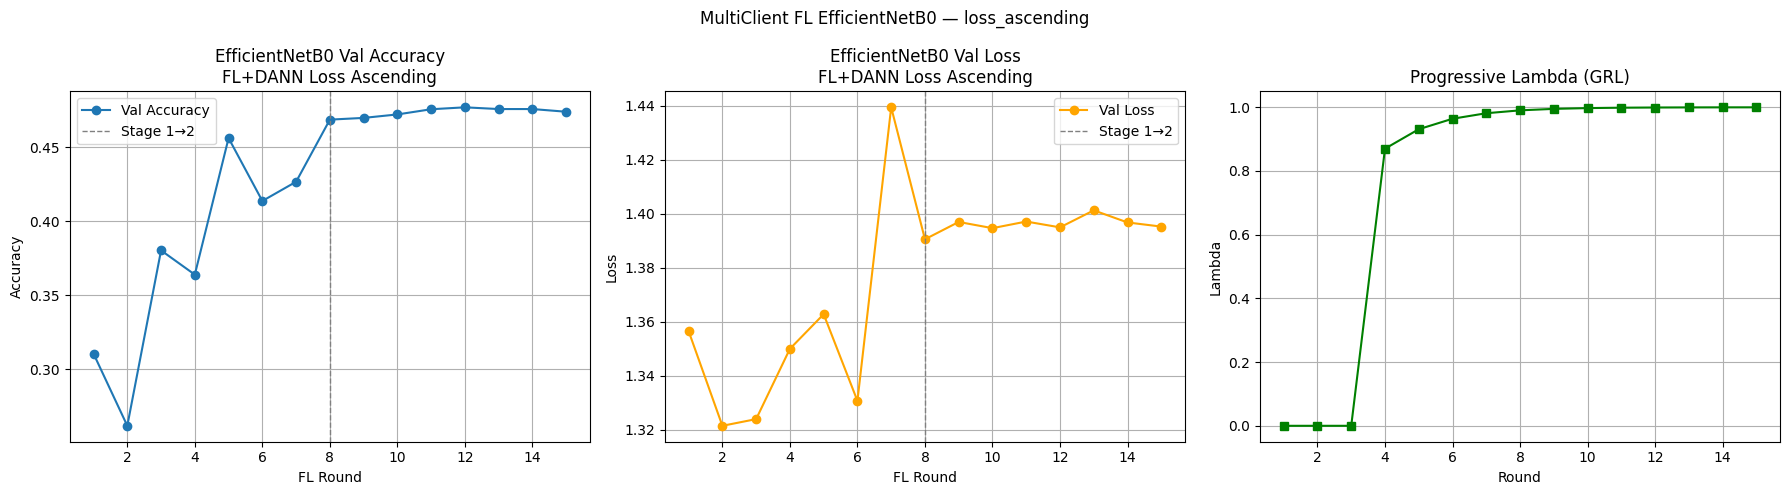

Saved: fl_training_curve.png


In [17]:
# =========================
# CELL 15 — PLOT FL TRAINING CURVE
# =========================
rounds_list   = [r["round"]        for r in fl_round_logs]
val_acc_list  = [r["val_accuracy"] for r in fl_round_logs]
val_loss_list = [r["val_loss"]     for r in fl_round_logs]
stage2_start  = next((r["round"] for r in fl_round_logs if r["stage"] == 2), None)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(rounds_list, val_acc_list, marker="o", label="Val Accuracy")
if stage2_start: axes[0].axvline(x=stage2_start, color="gray", linestyle="--", linewidth=1, label="Stage 1→2")
axes[0].set_title("EfficientNetB0 Val Accuracy\nFL+DANN Loss Ascending")
axes[0].set_xlabel("FL Round"); axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(rounds_list, val_loss_list, marker="o", color="orange", label="Val Loss")
if stage2_start: axes[1].axvline(x=stage2_start, color="gray", linestyle="--", linewidth=1, label="Stage 1→2")
axes[1].set_title("EfficientNetB0 Val Loss\nFL+DANN Loss Ascending")
axes[1].set_xlabel("FL Round"); axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(True)

# Lambda schedule
axes[2].plot(rounds_list, [r["lambda_grl"] for r in fl_round_logs], marker="s", color="green")
axes[2].set_title("Progressive Lambda (GRL)"); axes[2].set_xlabel("Round"); axes[2].set_ylabel("Lambda"); axes[2].grid(True)

plt.suptitle(f"MultiClient FL EfficientNetB0 — {SORT_STRATEGY}", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fl_training_curve.png"), dpi=300, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: fl_training_curve.png")

In [18]:
# =========================
# CELL 16 — BUILD PREDICTION OBJECTS
# =========================
test_probs = global_model.predict_labels(test_ds_global, verbose=1)
test_preds = np.argmax(test_probs, axis=1)
y_true     = np.array(y_test_global)
y_pred     = np.array(test_preds)
y_prob     = np.array(test_probs)
print("y_true:", y_true.shape, "| y_pred:", y_pred.shape, "| y_prob:", y_prob.shape)

y_true: (7698,) | y_pred: (7698,) | y_prob: (7698, 5)


In [19]:
# =========================
# CELL 17 — MAIN SUMMARY TABLE
# =========================
acc = accuracy_score(y_true, y_pred)
precision_macro,    recall_macro,    f1_macro,    _ = precision_recall_fscore_support(y_true, y_pred, average="macro",    zero_division=0)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
y_true_bin       = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
auc_macro_ovr    = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
auc_weighted_ovr = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="weighted")
summary_df = pd.DataFrame([{
    "experiment_name": EXPERIMENT_NAME, "model_name": MODEL_NAME,
    "setup": f"FL+DANN {SORT_STRATEGY}" if True else f"FL {SORT_STRATEGY}",
    "accuracy": acc, "precision_macro": precision_macro, "recall_macro": recall_macro,
    "f1_macro": f1_macro, "precision_weighted": precision_weighted,
    "recall_weighted": recall_weighted, "f1_weighted": f1_weighted,
    "auc_macro_ovr": auc_macro_ovr, "auc_weighted_ovr": auc_weighted_ovr,
    'best_val_acc': best_val_acc, 'lambda_gamma': LAMBDA_GAMMA,
    "fl_rounds": FL_ROUNDS,
}])
display(summary_df)
summary_df.to_csv( os.path.join(LOGS_DIR, "baseline_summary_table.csv"),  index=False)
summary_df.to_json(os.path.join(LOGS_DIR, "baseline_summary_table.json"), orient="records", indent=4)
print("Saved.")

,experiment_name,model_name,setup,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auc_macro_ovr,auc_weighted_ovr,best_val_acc,lambda_gamma,fl_rounds
0,exp6_fl_dann_loss_asc,efficientnetb0,FL+DANN loss_ascending,0.475578,0.314535,0.368897,0.281154,0.614364,0.475578,0.514322,0.663964,0.650154,0.476871,10.0,15


Saved.


In [20]:
# =========================
# CELL 18 — CLASSIFICATION REPORT
# =========================
report_text = classification_report(y_true, y_pred, digits=4)
print(report_text)
with open(os.path.join(LOGS_DIR, "classification_report_test.txt"),  "w") as f: f.write(report_text)
with open(os.path.join(LOGS_DIR, "classification_report_test.json"), "w") as f:
    json.dump(classification_report(y_true, y_pred, digits=4, output_dict=True), f, indent=4)
print("Saved.")

              precision    recall  f1-score   support

           0     0.7972    0.6227    0.6992      5083
           1     0.1032    0.2089    0.1381       517
           2     0.3409    0.0934    0.1467      1616
           3     0.2415    0.2923    0.2645       195
           4     0.0899    0.6272    0.1573       287

    accuracy                         0.4756      7698
   macro avg     0.3145    0.3689    0.2812      7698
weighted avg     0.6144    0.4756    0.5143      7698

Saved.


In [21]:
# =========================
# CELL 19 — PER-CLASS METRICS
# =========================
precision_cls, recall_cls, f1_cls, support_cls = precision_recall_fscore_support(
    y_true, y_pred, labels=np.arange(NUM_CLASSES), zero_division=0)
per_class_df = pd.DataFrame({"class": np.arange(NUM_CLASSES), "precision": precision_cls,
    "recall": recall_cls, "f1_score": f1_cls, "support": support_cls})
display(per_class_df)
per_class_df.to_csv( os.path.join(LOGS_DIR, "per_class_metrics.csv"),  index=False)
per_class_df.to_json(os.path.join(LOGS_DIR, "per_class_metrics.json"), orient="records", indent=4)
print("Saved.")

,class,precision,recall,f1_score,support
0,0,0.797229,0.622664,0.699216,5083
1,1,0.103152,0.208897,0.138107,517
2,2,0.340858,0.093441,0.146673,1616
3,3,0.241525,0.292308,0.264501,195
4,4,0.089910,0.627178,0.157274,287


Saved.


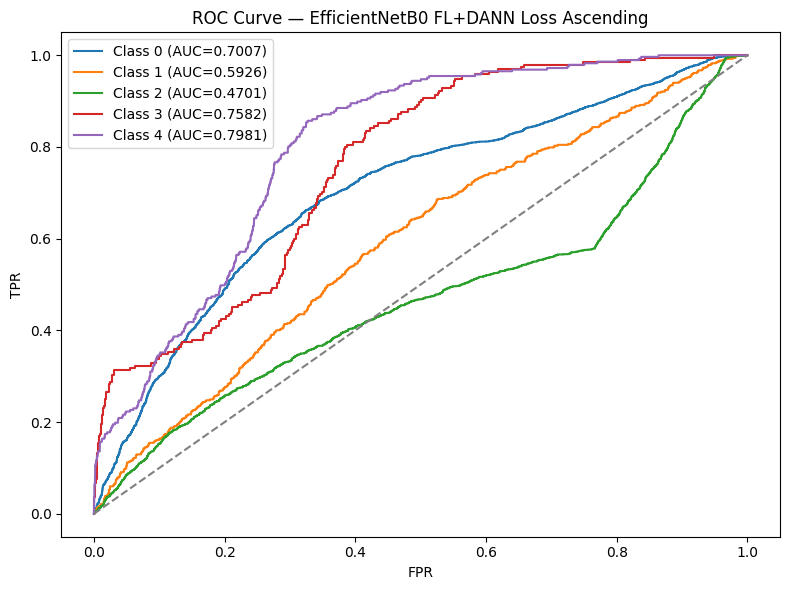

Saved.


In [22]:
# =========================
# CELL 20 — ROC CURVE + AUC
# =========================
y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
roc_auc_dict = {}
plt.figure(figsize=(8, 6))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    auc_val = auc(fpr, tpr); roc_auc_dict[f"class_{i}"] = float(auc_val)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc_val:.4f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.title(f"ROC Curve — EfficientNetB0 FL+DANN Loss Ascending"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "roc_curve_baseline.png"), dpi=300, bbox_inches="tight")
plt.show(); plt.close()
with open(os.path.join(LOGS_DIR, "roc_auc_per_class.json"), "w") as f: json.dump(roc_auc_dict, f, indent=4)
print("Saved.")

<Figure size 700x600 with 0 Axes>

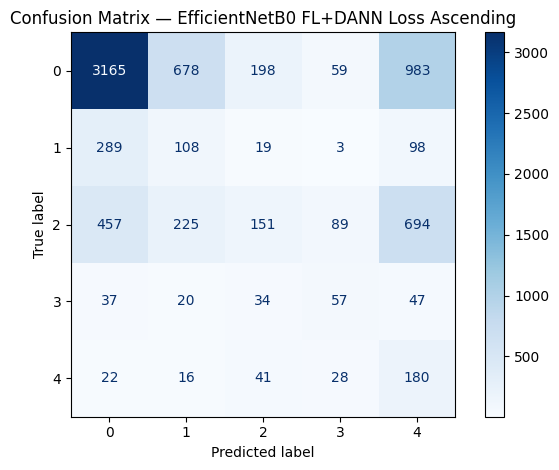

Saved.


In [23]:
# =========================
# CELL 21 — CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=np.arange(NUM_CLASSES)).plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — EfficientNetB0 FL+DANN Loss Ascending"); plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "confusion_matrix_heatmap_baseline.png"), dpi=300, bbox_inches="tight")
plt.show(); plt.close()
cm_df = pd.DataFrame(cm, index=[f"true_{i}" for i in range(NUM_CLASSES)],
                     columns=[f"pred_{i}" for i in range(NUM_CLASSES)])
cm_df.to_csv(os.path.join(LOGS_DIR, "confusion_matrix_table.csv"))
with open(os.path.join(LOGS_DIR, "confusion_matrix_values_test.json"), "w") as f:
    json.dump({"confusion_matrix": cm.tolist()}, f, indent=4)
print("Saved.")

In [24]:
# =========================
# CELL 22 — PER-CLIENT FINAL EVALUATION
# =========================
print("Per-Client Performance on Test Set")
print("=" * 60)
per_client_results = []
for i, (name, (X_te, y_te)) in enumerate(zip(CLIENT_NAMES, client_test_data)):
    te_ds = make_eval_dataset(X_te, y_te)
    probs_i = global_model.predict_labels(te_ds, verbose=0)
    preds_i = np.argmax(probs_i, axis=1)
    y_bin_i = label_binarize(y_te, classes=np.arange(NUM_CLASSES))
    c_acc           = accuracy_score(y_te, preds_i)
    c_p, c_r, c_f1, _ = precision_recall_fscore_support(y_te, preds_i, average="macro", zero_division=0)
    try:    c_auc = roc_auc_score(y_bin_i, probs_i, multi_class="ovr", average="macro")
    except: c_auc = None
    auc_str = f"{c_auc:.4f}" if c_auc is not None else "N/A"
    per_client_results.append({
        "client": name, "n_test_samples": int(len(y_te)),
        "accuracy": round(c_acc, 4), "precision_macro": round(c_p, 4),
        "recall_macro": round(c_r, 4), "f1_macro": round(c_f1, 4),
        "auc_macro_ovr": round(c_auc, 4) if c_auc is not None else None,
    })
    print(f"  {name:<10} | n={len(y_te):>5,} | Acc={c_acc:.4f} | F1={c_f1:.4f} | AUC={auc_str}")
per_client_df = pd.DataFrame(per_client_results)
display(per_client_df)
per_client_df.to_csv( os.path.join(LOGS_DIR, "per_client_test_metrics.csv"),  index=False)
per_client_df.to_json(os.path.join(LOGS_DIR, "per_client_test_metrics.json"), orient="records", indent=4)
print("Saved.")

Per-Client Performance on Test Set
  DDR        | n=1,879 | Acc=0.0729 | F1=0.0272 | AUC=0.4832
  EyePACS    | n=5,269 | Acc=0.6223 | F1=0.3548 | AUC=0.7386
  APTOS      | n=  550 | Acc=0.4455 | F1=0.3140 | AUC=0.7417


,client,n_test_samples,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr
0,DDR,1879,0.0729,0.0146,0.2000,0.0272,0.4832
1,EyePACS,5269,0.6223,0.3606,0.3756,0.3548,0.7386
2,APTOS,550,0.4455,0.3941,0.3498,0.3140,0.7417


Saved.


In [25]:
# =========================
# CELL 23 — COMPARISON READY JSON
# =========================
comparison_row = {
    "method"  : f"FL_DANN_{SORT_STRATEGY}",
    "model"   : MODEL_NAME, "dataset": DATASET_NAME, "clients": CLIENT_NAMES,
    "accuracy": float(acc), "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro), "f1_macro": float(f1_macro),
    "auc_macro_ovr": float(auc_macro_ovr), "fl_rounds": FL_ROUNDS,
    'best_val_acc': float(best_val_acc), 'lambda_gamma': LAMBDA_GAMMA,
    "notes": "EfficientNetB0, FL+DANN Loss Ascending, MultiClient (DDR+EyePACS+APTOS)."
}
with open(os.path.join(LOGS_DIR, "comparison_ready_baseline.json"), "w") as f:
    json.dump(comparison_row, f, indent=4)
print("Saved: comparison_ready_baseline.json")
print(json.dumps(comparison_row, indent=4))

Saved: comparison_ready_baseline.json
{
    "method": "FL_DANN_loss_ascending",
    "model": "efficientnetb0",
    "dataset": "MultiClient",
    "clients": [
        "DDR",
        "EyePACS",
        "APTOS"
    ],
    "accuracy": 0.47557807222655235,
    "precision_macro": 0.3145348766114095,
    "recall_macro": 0.36889745068806334,
    "f1_macro": 0.28115427352178,
    "auc_macro_ovr": 0.6639640904031373,
    "fl_rounds": 15,
    "best_val_acc": 0.4768711018711019,
    "lambda_gamma": 10.0,
    "notes": "EfficientNetB0, FL+DANN Loss Ascending, MultiClient (DDR+EyePACS+APTOS)."
}


In [27]:
# =========================
# CELL LAST — CONDITIONAL AUTO SHUTDOWN
# =========================
import time
from google.colab import runtime

# Cek apakah semua file output tersimpan
required_files = [
    os.path.join(LOGS_DIR, "baseline_summary_table.json"),
    os.path.join(LOGS_DIR, "fl_round_logs.json"),
    os.path.join(FIGURES_DIR, "fl_training_curve.png"),
]

all_saved = all(os.path.exists(f) for f in required_files)

print("=" * 55)
print("  OUTPUT FILES CHECK")
print("=" * 55)
for f in required_files:
    status = "✅" if os.path.exists(f) else "❌"
    print(f"  {status} {os.path.basename(f)}")

print()

if all_saved:
    print("  Semua output tersimpan ✅")
    print("  Runtime akan dimatikan dalam 15 detik...")
    time.sleep(15)
    runtime.unassign()
else:
    print("  ⚠️ Ada file yang belum tersimpan!")
    print("  Auto-shutdown dibatalkan — cek output di atas.")

  OUTPUT FILES CHECK
  ✅ baseline_summary_table.json
  ✅ fl_round_logs.json
  ✅ fl_training_curve.png

  Semua output tersimpan ✅
  Runtime akan dimatikan dalam 15 detik...
